# WASD2
WASD2 is a game wherein you see a sequence of 2 letters. this makes the game a bit harder since you have to first enter the first letter and then enter the second letter. this introduces a new challenge for the model, remembering its previous action. after trying it out with the resources i used in other challenges i came to the conclusion that i should use different technologies (maybe RNN or LSTM).

with a 3 frame stack model and training for 3000 episodes it does sometimes get good runs, but it still needs a lot of training to be flawless. (Highscore of 44 -> 88 actions correctly in a row)

installs
- gymnasium: 0.29.1
- pygame
- matplotlib: 3.9.2
- torch: 2.4.1+cpu
- torchvision: 0.19.1+cpu
- torchaudio: 2.4.1+cpu
- torchsummary

In [1]:
import gymnasium as gym
import matplotlib
import torch
import torchvision
import torchaudio
import torchsummary

print(gym.__version__)          # 0.29.1
print(matplotlib.__version__)   # 3.9.2
print(torch.__version__)        # 2.4.1
print(torchvision.__version__)  # 0.19.1
print(torchaudio.__version__)   # 2.4.1

0.29.1
3.9.2
2.4.1+cpu
0.19.1+cpu
2.4.1+cpu


1. Setup the CNN for Q-Learning

In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from collections import deque
from torchvision import transforms

STACK_SIZE = 3

# Define the CNN Q-network
class DQNCNN(nn.Module):
    def __init__(self, action_size):
        super(DQNCNN, self).__init__()
        self.conv1 = nn.Conv2d(STACK_SIZE, 64, kernel_size=3, stride=2)  # Using default stride and padding
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Reduces size further

        # Adjust this size based on your calculations
        self.fc1 = nn.Linear(64 * 20 * 20, 512)
        self.fc2 = nn.Linear(512, action_size)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)  # Apply max pooling to reduce size further
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


2. Preprocessing Function

In [3]:
# Preprocess the frames (resize and convert to grayscale)
def preprocess_frame(frame):
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Grayscale(),  # Convert to grayscale
        transforms.Resize((84, 84)),  # Resize to 84x84
        transforms.ToTensor(),  # Convert to tensor, will have shape [1, 84, 84]
    ])
    return transform(frame).squeeze(0)  # Remove the single channel dimension, resulting in [84, 84]


# Stack 4 frames
def stack_frames(frames):
    return np.stack(frames, axis=0)  # Shape will be [4, 84, 84]


3. Experience Replay Buffer

In [4]:
# Replay buffer to store past experiences
class ReplayBuffer:
    def __init__(self, buffer_size=10000):
        self.memory = deque(maxlen=buffer_size)

    def add(self, experience):
        self.memory.append(experience)

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)


4. DQN Agent

In [5]:
class DQNAgent:
    def __init__(self, action_size):
        self.action_size = action_size
        self.memory = ReplayBuffer(buffer_size=10000) 
        self.gamma = 0.99  # Discount factor
        self.epsilon = 0.4  # Exploration rate
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.batch_size = 64
        self.update_frequency = 4

        # Create two networks: one for the current Q-function and one for the target Q-function
        self.q_network = DQNCNN(action_size)
        self.target_network = DQNCNN(action_size)
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=0.0001)

        # Copy weights from the current network to the target network
        self.target_network.load_state_dict(self.q_network.state_dict())

    def select_action(self, state, explore=True):
        # During exploration, select a random action
        if explore and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        
        # During exploitation, select the action with the highest Q-value
        state = torch.FloatTensor(state).unsqueeze(0)  # Convert to tensor and add batch dimension
        q_values = self.q_network(state)
        return torch.argmax(q_values).item()

    def replay(self):
        if len(self.memory) < self.batch_size:
            return

        minibatch = self.memory.sample(self.batch_size)
        states, actions, rewards, next_states, dones = zip(*minibatch)

        # Convert to numpy arrays before converting to tensors
        states = torch.FloatTensor(np.array(states))
        next_states = torch.FloatTensor(np.array(next_states))
        actions = torch.LongTensor(actions)
        rewards = torch.FloatTensor(rewards)
        dones = torch.FloatTensor(dones)

        # Get current Q values
        q_values = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Get target Q values
        next_q_values = self.target_network(next_states).max(1)[0]
        target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        # Compute loss
        loss = nn.MSELoss()(q_values, target_q_values.detach())
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Update epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def update_target_network(self):
        self.target_network.load_state_dict(self.q_network.state_dict())


5. Initialise Environment

In [14]:
from WASDEnv import WinFormsGameEnv

# env = gym.make('CartPole-v1', render_mode='rgb_array')
env = WinFormsGameEnv()

6. Initialise Agent

In [15]:
agent = DQNAgent(action_size=env.action_space.n)

In [16]:
agent

7. Training Loop

In [24]:
# Stack size for CNN input (4 stacked frames)
stack_size = STACK_SIZE
agent.q_network.train()

# Training loop
num_episodes = 500
for e in range(num_episodes):
    state_stack = deque(maxlen=stack_size)
    state, info = env.reset()
    
    # Initialize frame stack with initial frame
    frame = preprocess_frame(env.render())
    for _ in range(stack_size):
        state_stack.append(frame)

    done = False
    total_reward = 0
    while not done:
        env.render()
        state = stack_frames(state_stack)

        # Choose an action
        action = agent.select_action(state)
        
        # Perform action
        next_state, reward, done, _, _ = env.step(action)
        
        # Process next state (frame) and add to the stack
        next_frame = preprocess_frame(env.render())
        state_stack.append(next_frame)
        next_state_stack = stack_frames(state_stack)

        # Store experience in replay memory
        agent.memory.add((state, action, reward, next_state_stack, done))
        
        # Train the agent with experience replay
        agent.replay()

        # Update the state
        state_stack = state_stack

        total_reward += reward
        
        # Periodically update target network
        if e % agent.update_frequency == 0:
            agent.update_target_network()

    print(f"Episode: {e+1}/{num_episodes}, Total Reward: {total_reward}")

env.close()


Episode: 1/500, Total Reward: 0
Episode: 2/500, Total Reward: 0
Episode: 3/500, Total Reward: 0
Episode: 4/500, Total Reward: 0
Episode: 5/500, Total Reward: 2
Episode: 6/500, Total Reward: 0
Episode: 7/500, Total Reward: 0
Episode: 8/500, Total Reward: 0
Episode: 9/500, Total Reward: 0
Episode: 10/500, Total Reward: 0
Episode: 11/500, Total Reward: 0
Episode: 12/500, Total Reward: 0
Episode: 13/500, Total Reward: 0
Episode: 14/500, Total Reward: 0
Episode: 15/500, Total Reward: 0
Episode: 16/500, Total Reward: 0
Episode: 17/500, Total Reward: 0
Episode: 18/500, Total Reward: 0
Episode: 19/500, Total Reward: 0
Episode: 20/500, Total Reward: 0
Episode: 21/500, Total Reward: 8
Episode: 22/500, Total Reward: 0
Episode: 23/500, Total Reward: 0
Episode: 24/500, Total Reward: 0
Episode: 25/500, Total Reward: 0
Episode: 26/500, Total Reward: 0
Episode: 27/500, Total Reward: 0
Episode: 28/500, Total Reward: 0
Episode: 29/500, Total Reward: 6
Episode: 30/500, Total Reward: 0
Episode: 31/500, To

8. Save Model Weights

In [25]:
import torch

# Assuming `agent` is your trained model and `path_to_save` is the file path
torch.save(agent.q_network.state_dict(), './model/q_network_3000.pth')
torch.save(agent.target_network.state_dict(), './model/target_network_3000.pth')

9. Load Model Weights

In [17]:
import torch

# Assuming `Agent` is your model class
agent.q_network = DQNCNN(env.action_space.n)  # Initialize the model architecture
agent.q_network.load_state_dict(torch.load('./model-3/q_network_3000.pth'))

agent.target_network = DQNCNN(env.action_space.n)  # Initialize the model architecture
agent.target_network.load_state_dict(torch.load('./model-3/target_network_3000.pth'))

# Ensure the models are in evaluation mode
agent.q_network.eval()
agent.target_network.eval()


C:\Users\Kaan\AppData\Local\Temp\ipykernel_14984\4033063193.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  agent.q_network.load_state_dict(torch.load('./model-3/q_netwo

DQNCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=25600, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=4, bias=True)
)

10. Testing Loop

In [19]:
import matplotlib.pyplot as plt 

# Testing loop (after training)
num_test_episodes = 3
stack_size = STACK_SIZE
all_rewards = 0

for e in range(num_test_episodes):
    state_stack = deque(maxlen=stack_size)
    state, info = env.reset()

    # Initialize frame stack with the first frame
    frame = preprocess_frame(env.render())
    for _ in range(stack_size):
        state_stack.append(frame)

    done = False
    total_reward = 0

    while not done:
        # Render the frame
        # clear_output(wait=True)
        # plt.imshow(env.render())
        # plt.axis('off')  # Turn off the axis

        state = stack_frames(state_stack)

        # Use the trained model to select an action (no exploration during testing)
        action = agent.select_action(state, explore=False)  # No exploration in testing

        # Perform the action in the environment
        next_state, reward, done, _, _ = env.step(action)

        # Process the next state (frame) and update the frame stack
        next_frame = preprocess_frame(env.render())
        state_stack.append(next_frame)

        total_reward += reward

        # Update the plot with the new frame
        # plt.title(f"Test Episode: {e + 1}/{num_test_episodes}, Total Reward: {total_reward}")
        # plt.pause(0.001)  # Short pause to allow plot to update

    print(f"Test Episode: {e + 1}/{num_test_episodes}, Total Reward: {total_reward}")
    all_rewards += total_reward
print(f'avg score: {all_rewards/num_test_episodes}')
env.close()


Test Episode: 1/3, Total Reward: 0
Test Episode: 2/3, Total Reward: 0
Test Episode: 3/3, Total Reward: 30
avg score: 10.0


# Visualizing Model
Using a gradcam to see what the model looks at

In [20]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Use only full backward hook (recommended)
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_action_idx):
        self.model.eval()
        self.model.zero_grad()

        output = self.model(input_tensor)
        target = output[0, target_action_idx]
        target.backward()

        if self.gradients is None or self.activations is None:
            raise ValueError("Gradients or activations not captured.")

        # Global average pooling on gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        # Normalize
        cam = cam.squeeze().cpu().numpy()
        cam -= cam.min()
        cam /= cam.max() + 1e-8

        return cam


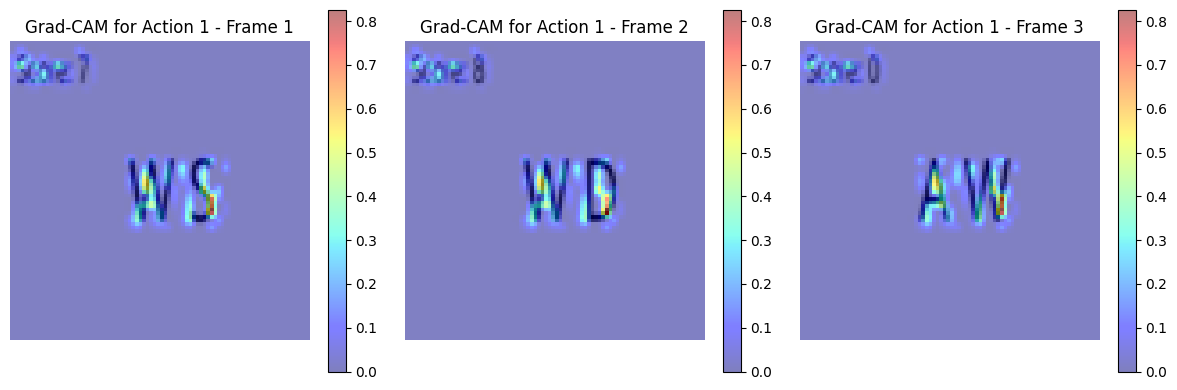

In [22]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch

# Assume state_stack is a deque of 3 grayscale frames of shape [84, 84]
frame_stack = list(state_stack)  # Convert deque to list if necessary
device = torch.device("cpu")

# Stack frames into shape: [3, 84, 84]
frame_stack_np = np.stack(frame_stack, axis=0).astype(np.float32)

# Convert to torch tensor: shape [1, 3, 84, 84]
input_tensor = torch.from_numpy(frame_stack_np).unsqueeze(0).to(device)

# Forward pass & Grad-CAM
model = agent.q_network
gradcam = GradCAM(model, model.conv1)
q_values = model(input_tensor)
action = torch.argmax(q_values).item()
heatmap = gradcam.generate(input_tensor, action)

# Resize heatmap to match input
heatmap_resized = cv2.resize(heatmap, (84, 84))

# Plot each frame with its corresponding heatmap
plt.figure(figsize=(12, 4))

for idx in range(3):  # Loop through each frame in the stack
    plt.subplot(1, 3, idx + 1)
    base_img = frame_stack_np[idx]  # Pick the current frame in the stack
    plt.imshow(base_img, cmap='gray')
    plt.imshow(heatmap_resized, cmap='jet', alpha=0.5)
    plt.title(f"Grad-CAM for Action {action} - Frame {idx + 1}")
    plt.colorbar()
    plt.axis('off')

plt.tight_layout()
plt.show()


# Conclusion
The model still has a hard time understanding the fact that it is doing a sequential task. To make the model stronger I could look into RNN models.